In [1]:
%reload_ext autoreload
%autoreload 2

import json

In [3]:
# from ../validating/fit_np_to_np/check_likelihood.ipynb
var_dict = dict(
    theta_pib = [1., 0., 0.], # O A F
    theta_ics = [1., 0., 0.],
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.3, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = [1., 0., 0., 0., 0.],
    theta_bulge_ps = [0., 1., 0., 0., 0.],
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
json.dump(var_dict, open('truth_dict_base230927.json', 'w'), indent=4)

In [2]:
prior_dict = dict(
    theta_pib = 'Dirichlet',
    theta_ics = 'Dirichlet',
    S_iso = [1e-3, 5],
    S_bub = [1e-3, 5],
    S_psc = [1e-3, 5],
    S_pib = [1e-3, 14],
    S_ics = [1e-3, 14],
    Sps_dsk = [1e-3, 4],
    zs = [0.1, 2.5],
    C = [0.05, 8.],
    S_gce = [1e-5, 4],
    gamma_poiss = [0.2, 2.],
    f_bulge_poiss = [0, 1],
    Sps_gce = [1e-3, 4],
    gamma_ps = [0.2, 2.],
    f_bulge_ps = [0, 1],
    theta_bulge_poiss = 'Dirichlet',
    theta_bulge_ps = 'Dirichlet',
    n1_dsk = [4., 6.],
    n2_dsk = [0.5, 1.99],
    n3_dsk = [-6., -5.],
    sb1_dsk = [5., 40.],
    lambdas_dsk = [0.1, 0.95],
    n1_gce = [4., 6.],
    n2_gce = [0.5, 1.99],
    n3_gce = [-6., -5.],
    sb1_gce = [5., 40.],
    lambdas_gce = [0.1, 0.95],
    Alm_0 = [-0.05, 0.05],
    Alm_1 = [-0.05, 0.05],
    Alm_2 = [-0.05, 0.05],
    Alm_3 = [-0.05, 0.05],
    Alm_4 = [-0.05, 0.05],
    Alm_5 = [-0.05, 0.05],
)
json.dump(prior_dict, open('prior_dict_base230927.json', 'w'), indent=4)

# TMP

In [4]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def dnds(s, theta):

    a, n1, n2, n3, sb1, sb2 = theta
    dnds = a * (sb2 / sb1) ** -n2 * jnp.where(s < sb2, (s / sb2) ** (-n3), jnp.where((s >= sb2) * (s < sb1), (s / sb2) ** (-n2), (sb1 / sb2) ** (-n2) * (s / sb1) ** (-n1)))
    return dnds

def dnds_1b(s, theta):

    a, n1, n2, sb = theta
    dnds = jnp.where(s < sb, a * (s / sb) ** -n2, a * (s / sb) ** -n1)
    return dnds

In [6]:
s = jnp.logspace(-1, 2, 1000)
# a, n1, n2, n3, sb1, sb2 = 1, 5, 1, -6, 11, 4
a, n1, n2, n3, sb1, sb2 = 1, 5, 0, -6, 10, 3
dnds = a * (sb2 / sb1) ** -n2 * jnp.where(s < sb2, (s / sb2) ** (-n3), jnp.where((s >= sb2) * (s < sb1), (s / sb2) ** (-n2), (sb1 / sb2) ** (-n2) * (s / sb1) ** (-n1)))

(0.1, 10.0)

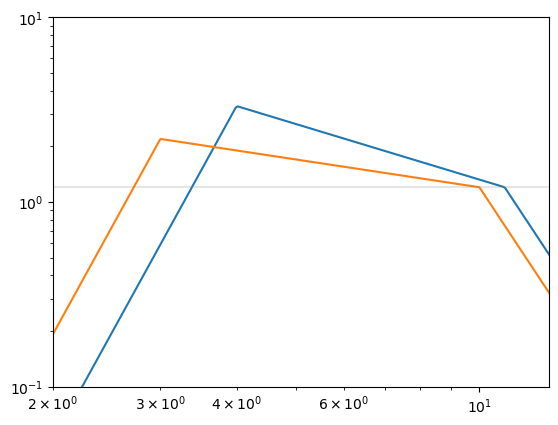

In [10]:
s = jnp.logspace(-1, 2, 1000)
dnds1 = dnds(s, [1.2, 5, 1, -6, 11, 4])
dnds2 = dnds(s, [1.2, 5, 0.5, -6, 10, 3])
plt.plot(s, dnds1)
plt.plot(s, dnds2)
plt.axhline(1.2, color='gray', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlim(2, 13)
plt.ylim(1e-1, 1e1)

(0.1, 10.0)

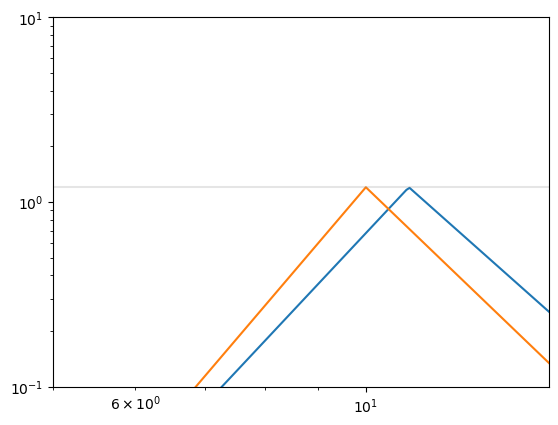

In [12]:
s = jnp.logspace(-1, 2, 1000)
dnds1 = dnds_1b(s, [1.2, 5, -6, 11])
dnds2 = dnds_1b(s, [1.2, 5.4, -6.6, 10])
plt.plot(s, dnds1)
plt.plot(s, dnds2)
plt.axhline(1.2, color='gray', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlim(5, 15)
plt.ylim(1e-1, 1e1)